In [7]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso


In [2]:
x, y = make_regression(n_samples = 100 , n_features = 1 , n_informative = 1 , n_targets = 1 , noise = 20 , random_state = 13 )


In [5]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 2)
lr = LinearRegression()


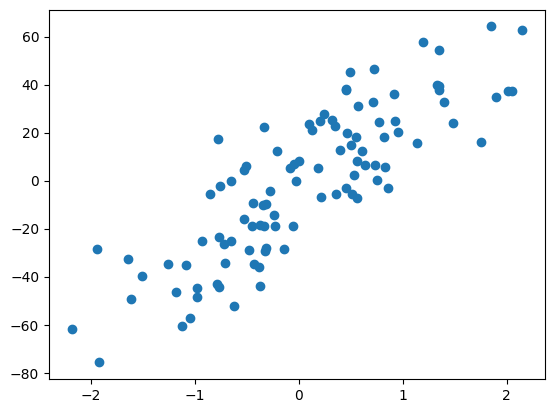

In [6]:
plt.scatter(x, y)

In [8]:
lr.fit(x_train , y_train)
y_pred = lr.predict(x_test)
print(lr.intercept_)
print(lr.coef_)

-2.2710144261783825
[28.12597332]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)


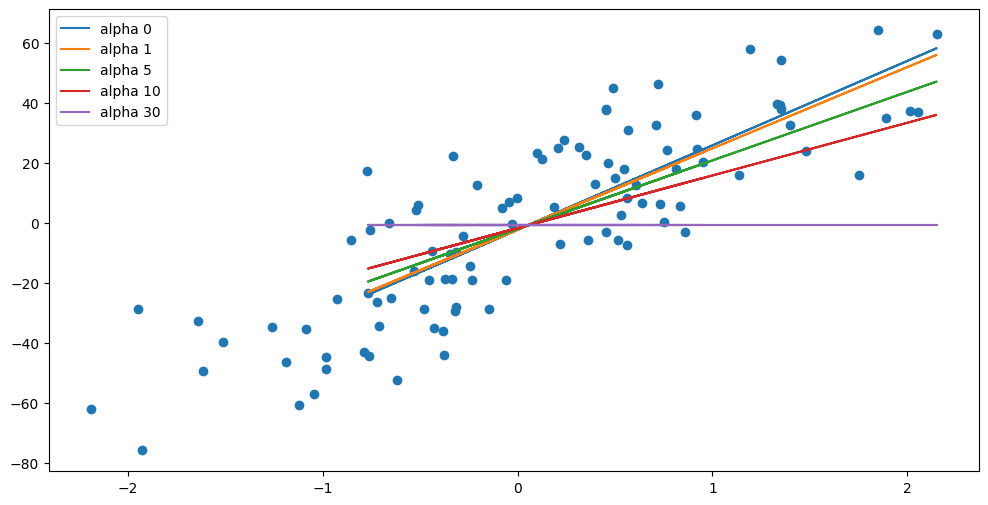

In [12]:
alphas = [0, 1, 5, 10 , 30]
plt.figure(figsize = (12, 6))
plt.scatter( x, y )

for i in (alphas) :
    l = Lasso(alpha = i)
    l.fit(x_train , y_train)
    plt.plot(x_test , l.predict(x_test) , label = 'alpha {}'.format(i))
plt.legend()
plt.show()

#applying lasso to polymial regression

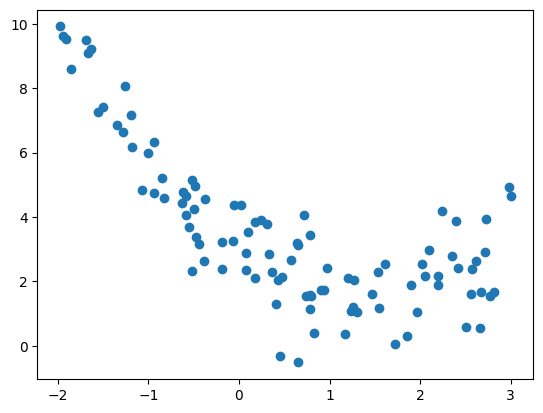

In [13]:
m = 100 
x1 = 5 * np.random.rand(m,1 ) -2 
x2 =  0.7* x1 **2 -2*x1 +3 + np.random.randn(m ,1)

plt.scatter(x1 , x2)
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.171998e+09, tolerance: 5.710e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did n

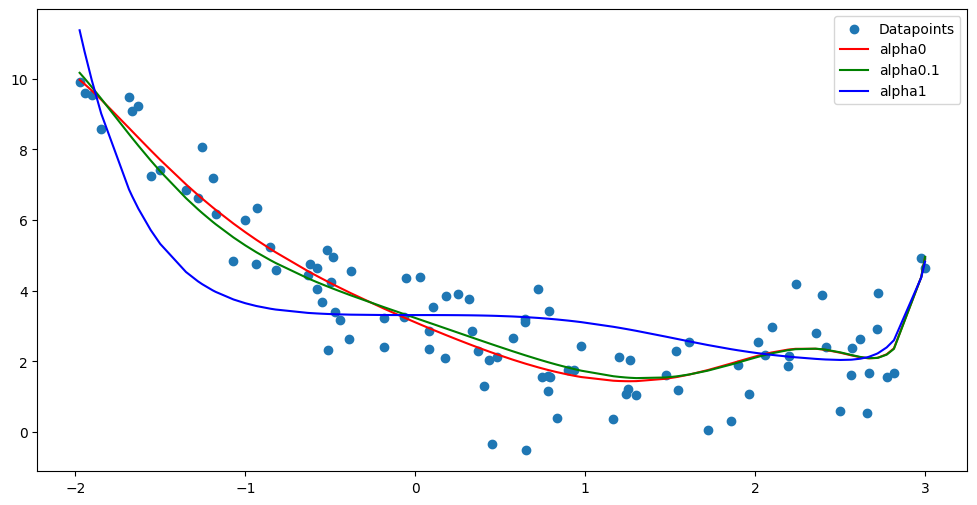

In [23]:
from typing import Any


from math import degrees
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso


#plt.scatter(x1 , x2)

def get_lasso_preds(x1, x2, alpha):
    pipeline = Pipeline([
        ('poly' , PolynomialFeatures(degree = 16)),
        ('lasso' , Lasso(alpha = alpha))
    ])
    pipeline.fit(x1, x2)
    return pipeline.predict(x1)



cs = [ 'r' , 'g' , 'b']
alphas = [ 0 , 0.1 , 1]


plt.figure(figsize = (12, 6))
plt.scatter(x1, x2 , label = 'Datapoints')

for alpha , c in zip(alphas , cs) :
    preds = get_lasso_preds(x1 , x2 , alpha)
    plt.plot(sorted(x1[: , 0]) , preds[np.argsort(x1[:, 0])] , c , label = 'alpha{}'.format(alpha))

plt.legend()
plt.show()

